In [ ]:
# we can able to create our word 2 vec

# Custom model development

# Fine tuning

**Concept of Word2Vec**

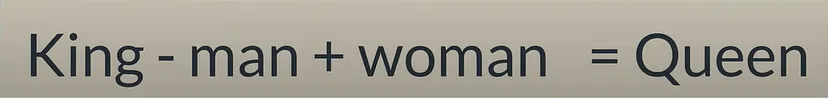

We can see that the angle between the **king** and **queen** vectors, and between the **man** and **woman** vectors, is very small, meaning that the similarity is near one.

Another cool thing about these word vectors is that you can mathematically construct word analogies.

So you can take the word vector for **king**, and subtract the word vector for **man**, thats what this dotted line represents, and then you can add the word vector for **woman** to that, that’s what this dotted green line represents, and you get the exact word vector for **queen**.



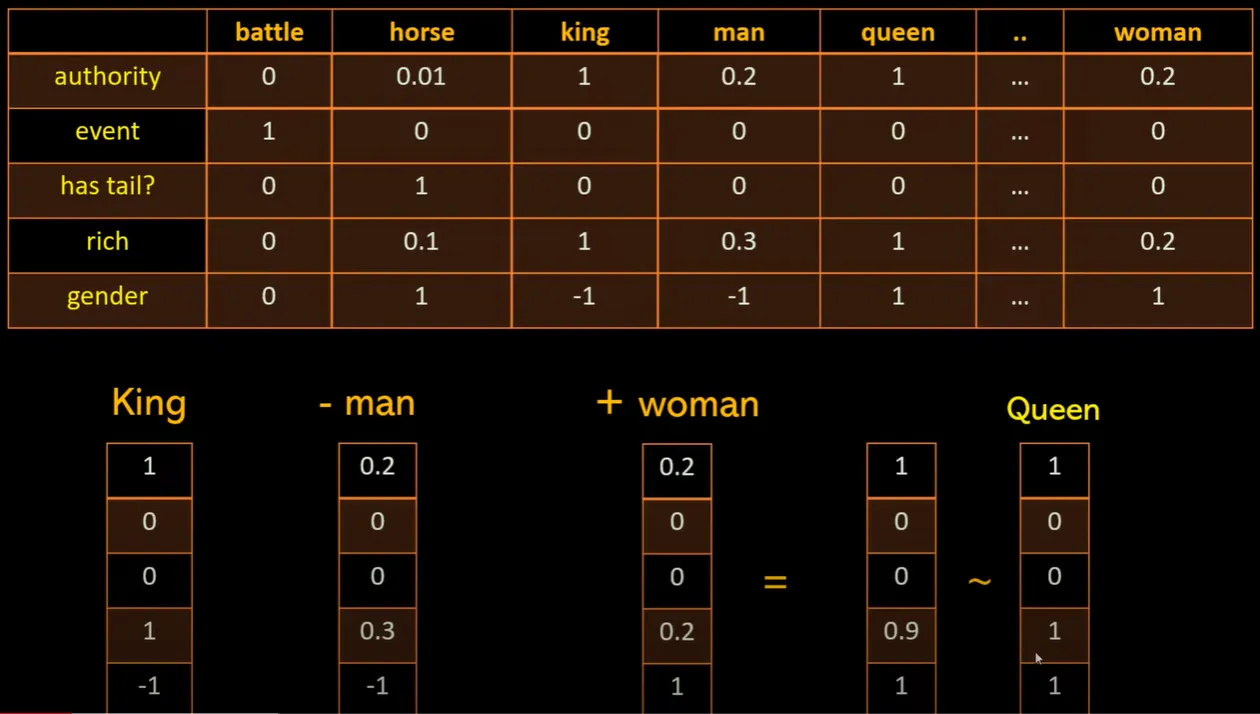

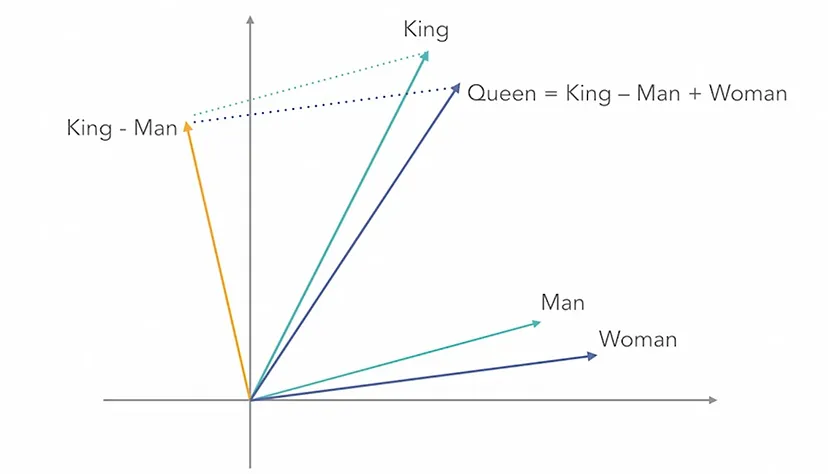

In [ ]:
!pip install --upgrade numpy==1.24.3

In [ ]:
!pip install gensim

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 86.7 MB/s eta 0:00:00


## Import packages

In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
import string
from gensim.models import Word2Vec
import numpy as np
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

## Read the data

In [ ]:
data = pd.read_excel('/content/IMDB Dataset_sample.xlsx')


In [ ]:
data.head(2)

,review,sentiment
0,One of the other reviewers has mentioned that ...,positive
1,A wonderful little production. <br /><br />The...,positive


## Split the data

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(data['review'],
                                                    data['sentiment'],
                                                    test_size=0.2,
                                                    random_state=42)

In [ ]:
X_train.shape,y_train.shape

((891,), (891,))

## We are individually importing the NLP packages

In [ ]:
import nltk
nltk.download('stopwords')
nltk.download('punkt_tab')

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


True

## Creating a preprocess function

- lower the text

- removing the punctuations

- tokenize the text

- Apply the stop words

In [ ]:
stop_words = set(stopwords.words('english'))
def preprocess(text):
    text = text.lower()
    text = ''.join([word for word in text if word not in string.punctuation])
    tokens = word_tokenize(text)
    tokens = [word for word in tokens if word not in stop_words]
    return ' '.join(tokens)
X_train = X_train.apply(preprocess)
X_test = X_test.apply(preprocess)

In [ ]:
X_train[0].split()

['one',
 'reviewers',
 'mentioned',
 'watching',
 '1',
 'oz',
 'episode',
 'youll',
 'hooked',
 'right',
 'exactly',
 'happened',
 'mebr',
 'br',
 'first',
 'thing',
 'struck',
 'oz',
 'brutality',
 'unflinching',
 'scenes',
 'violence',
 'set',
 'right',
 'word',
 'go',
 'trust',
 'show',
 'faint',
 'hearted',
 'timid',
 'show',
 'pulls',
 'punches',
 'regards',
 'drugs',
 'sex',
 'violence',
 'hardcore',
 'classic',
 'use',
 'wordbr',
 'br',
 'called',
 'oz',
 'nickname',
 'given',
 'oswald',
 'maximum',
 'security',
 'state',
 'penitentary',
 'focuses',
 'mainly',
 'emerald',
 'city',
 'experimental',
 'section',
 'prison',
 'cells',
 'glass',
 'fronts',
 'face',
 'inwards',
 'privacy',
 'high',
 'agenda',
 'em',
 'city',
 'home',
 'manyaryans',
 'muslims',
 'gangstas',
 'latinos',
 'christians',
 'italians',
 'irish',
 'moreso',
 'scuffles',
 'death',
 'stares',
 'dodgy',
 'dealings',
 'shady',
 'agreements',
 'never',
 'far',
 'awaybr',
 'br',
 'would',
 'say',
 'main',
 'appeal',

# Tokenization

In [ ]:
# Train the Word2Vec model
# we are calling each sentence from X_train
# we are spliting :  it becomes words
# we have 891 lists are there
# each list has words
sentences = [sentence.split() for sentence in X_train]
len(sentences)

891

In [ ]:
sentences[1]

['take',
 'cast',
 'experienced',
 'wellknown',
 'actors',
 'put',
 'together',
 'stupid',
 'movie',
 'nimrod',
 'antel',
 'answer',
 'armored',
 'six',
 'coworkers',
 'armored',
 'car',
 'business',
 'decide',
 'steal',
 'large',
 'shipment',
 'cash',
 'get',
 'first',
 'base',
 'plans',
 'everything',
 'unravels',
 'quickly',
 'plot',
 'like',
 'youd',
 'think',
 'couldnt',
 'bad',
 'least',
 'action',
 'movie',
 'however',
 'first',
 '40',
 'minutes',
 'movie',
 'see',
 'appear',
 '6',
 'normal',
 'everyday',
 'kind',
 'guys',
 'joke',
 'laugh',
 'drinks',
 'together',
 'etc',
 'suddenly',
 'learn',
 'theyre',
 'planning',
 'rob',
 'business',
 'hero',
 'ty',
 'columbus',
 'short',
 'sucked',
 'scheme',
 'cold',
 'cruel',
 'world',
 'even',
 'though',
 'hes',
 'decorated',
 'veteran',
 'nice',
 'guy',
 'reliable',
 'employee',
 'oh',
 'oh',
 'last',
 '40',
 'minutes',
 'film',
 'former',
 'regular',
 'guys',
 'nearly',
 'turn',
 'moneycrazed',
 'psychos',
 'willing',
 'butcher',
 'c

In [ ]:
len(sentences[0]),len(sentences[1])

(69, 140)

## Fine tune the word 2 vec model

**size** - size of the vectors we want

**window** - number words before and after the focus word that it’ll consider as context for the word

**min_count** - the number of times a word must appear in our corpus in order to create a word vector.

In [ ]:

w2v_model = Word2Vec(sentences, window=5, min_count=5, workers=4)
w2v_model
# default vector size =100

In [ ]:
 len(w2v_model.wv['king'])


100

In [ ]:
w2v_model.corpus_total_words

108286

In [ ]:
w2v_model.wv.most_similar('king')

[('john', 0.9994863271713257),
 ('original', 0.999484658241272),
 ('rather', 0.9994762539863586),
 ('comedy', 0.999472975730896),
 ('making', 0.9994687438011169),
 ('shot', 0.9994562864303589),
 ('doesnt', 0.9994527697563171),
 ('could', 0.9994505643844604),
 ('every', 0.9994449615478516),
 ('far', 0.9994422793388367)]

In [ ]:
# Take king_v  john_v apply cosine similarity

In [ ]:
w2v_model.wv['good']

# w2v_model.wv[word]

array([-2.10746795e-01,  4.47797447e-01,  2.11420476e-01, -9.88537297e-02,
        1.23732127e-01, -9.19766605e-01,  2.87216604e-01,  1.07488191e+00,
       -4.71582681e-01, -3.15771878e-01, -1.00746870e-01, -1.01493287e+00,
       -9.71974507e-02,  3.83137465e-01,  1.91418737e-01, -3.21789414e-01,
        1.93753377e-01, -6.49534225e-01, -1.34803010e-02, -8.59298170e-01,
        1.79986641e-01,  3.33444357e-01,  2.84308761e-01, -2.87904143e-01,
       -2.81980187e-01,  1.05742417e-01, -3.18089992e-01, -1.86050937e-01,
       -3.12606156e-01,  1.74217634e-02,  5.08146882e-01, -4.48305458e-02,
        1.09970436e-01, -3.89895231e-01, -6.34887442e-02,  5.92182934e-01,
       -1.17257647e-01, -5.74600160e-01, -2.83073694e-01, -9.94395256e-01,
       -6.32997379e-02, -5.06729066e-01, -1.78505078e-01, -8.08678567e-04,
        3.23402137e-01, -2.24122316e-01, -3.56602460e-01, -2.52548397e-01,
        3.28225315e-01,  4.06758934e-01,  2.61806190e-01, -4.88671452e-01,
       -1.91782087e-01, -

## Vectorization

- we have words and vectors are ready

- now we need to apply our entire IMDB data

- IMDB data has sentences

- will divide sentences into words

- if that words is present in word2vec corpus words, then take the vector

- other wise create a vector with zeros :  100

- also different sentences will have different words, each word has 100 length of vectors, so will apply mean of those all words vector to create a sentence vector

we are making our vetors values follows normal distribution

In [ ]:
'jhon' in w2v_model.wv

False

In [ ]:
np.array([np.zeros(5),np.ones(5)])

array([[0., 0., 0., 0., 0.],
       [1., 1., 1., 1., 1.]])

In [ ]:
np.array([np.zeros(5),np.ones(5)]).mean(axis=0)

array([0.5, 0.5, 0.5, 0.5, 0.5])

In [ ]:
def vectorize(sentence):
    words = sentence.split()
    words_vecs = [w2v_model.wv[word] for word in words if word in w2v_model.wv]
    if len(words_vecs) == 0:
        return np.zeros(100)
    words_vecs = np.array(words_vecs)
    return words_vecs.mean(axis=0)

In [ ]:
X_train = np.array([vectorize(sentence) for sentence in X_train])
X_test = np.array([vectorize(sentence) for sentence in X_test])

In [ ]:
#X_train

In [ ]:
len(X_train[0]),len(X_train)

(100, 891)

# Develop the ML model

In [ ]:
# Train a classification model
clf = LogisticRegression()
clf.fit(X_train, y_train)
# Evaluate the model
y_pred = clf.predict(X_test)

print('Accuracy:', accuracy_score(y_test, y_pred))
print('Precision:', precision_score(y_test, y_pred, pos_label='positive'))
print('Recall:', recall_score(y_test, y_pred, pos_label='positive'))
print('F1 score:', f1_score(y_test, y_pred, pos_label='positive'))

Accuracy: 0.5426008968609866
Precision: 0.5480769230769231
Recall: 0.5089285714285714
F1 score: 0.5277777777777778


# Unseen data

- Any unseen data need to perform same analysis that we have done on train data

- And same vector size is required

In [ ]:
X_test='bad movie'
X_test = preprocess(X_test)
X_test = np.array([vectorize(X_test)])
print(len(X_test))
clf.predict(X_test)

1


array(['negative'], dtype=object)

- 1.Word2Vec is a unsupervised algorithm

    - CBOW and SkipGram we are tryting find the relationship between words

- 2. Word2vec will not able discriminate the difference between good and bad  due to avg of vectors

- 3. we are not saying to word2vec you are doing a classification problem
        good [0.7,0.5]   postive   1
        bad  [-0.6,0.2]  negative  0

        - how much qulaity of emebedding vectors we have

        - how good the patterns are stored on vectors

- **We are moving Transformers : BERT models**

